# **Suicidality Classification from Reddit Posts**

This notebook consolidates all classification models developed for suicidality detection from Reddit posts. Five models are covered across two parts: K-Nearest Neighbors, Logistic Regression, and Multinomial Naive Bayes as traditional machine learning baselines, followed by a Neural Network on frozen BERT embeddings and a fine-tuned DistilBERT classifier as deep learning approaches. All models are trained on the same dataset split and evaluated on the same test set to ensure a fair and consistent comparison.

## **Environment Setup & Library Imports**

All necessary libraries are imported here. Random seeds are fixed across NumPy and PyTorch to ensure reproducibility.

In [1]:
%load_ext autoreload
%autoreload 2

# Basic
import re
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap
import joblib
from tqdm.auto import tqdm
from itertools import product

# Traditional ML
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    average_precision_score,
    f1_score,
    accuracy_score,
)
from scipy.sparse import hstack, csr_matrix

# Deep Learning
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam, AdamW
from torch.optim.lr_scheduler import StepLR
from torch.nn.utils import clip_grad_norm_
from transformers import (
    AutoTokenizer,
    AutoModel,
    DistilBertTokenizer,
    DistilBertForSequenceClassification,
    get_linear_schedule_with_warmup,
)

from utility import FeatureTransformer

random_seed = 42
np.random.seed(random_seed)
torch.manual_seed(random_seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

c:\MAIN_FILES\Documents\DLSU\3rd Year\2nd Term\STINTSY\MP\STINTSY-MCO\stintsy (3.13.6)\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu


## **Data Preparation**

We load the preprocessed dataset and establish consistent train/validation/test splits that are shared across all models. Using identical splits ensures that performance differences reflect the models themselves, not differences in what data they saw.

In [2]:
df = pd.read_csv("suicidality_dataset_w_features.csv", keep_default_na=False, index_col=0)
df.head()

,title,post,label,has_post,text,text_cleaned,sub_metal_health_count,sub_dark_count,sub_support_count,sub_total_count,...,emoticon_positive,emoticon_negative,emoticon_crying,emoticon_neutral,emoticon_heart,emoticon_broken_heart,emoji_negative,emoji_positive,emoji_crisis,emoji_implicit_distress
0,I'm looking for a girl I've met at the Polish ...,I've tried Polish spotted pages but I guess sh...,Non-Suicidal,1,I'm looking for a girl I've met at the Polish ...,I'm looking for a girl I've met at the Polish ...,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,I got a guy kicked off a domestic flight today.,I was in a forward row as we were boarding for...,Non-Suicidal,1,I got a guy kicked off a domestic flight today...,I got a guy kicked off a domestic flight today...,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,"My youngest got in school suspension, I’m so p...",So according to witness testimonies a boy grab...,Non-Suicidal,1,"My youngest got in school suspension, I’m so p...","My youngest got in school suspension, I’m so p...",0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,"I'm a cashier who switched from ""sir/mam"" to ""...","So as said in the title, I'm a cashier (well, ...",Non-Suicidal,1,"I'm a cashier who switched from ""sir/mam"" to ""...","I'm a cashier who switched from ""sir/mam"" to ""...",0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
4,My whole class complimented me and didn’t real...,"Today in class, we were doing this activity ca...",Non-Suicidal,1,My whole class complimented me and didn’t real...,My whole class complimented me and didn’t real...,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0


In [3]:
label_encoder = LabelEncoder()
label_encoder.fit(df["label"])
mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
mapping_inv = {v: k for k, v in mapping.items()}

print("Label Mapping:", mapping)

Label Mapping: {'Non-Suicidal': np.int64(0), 'Suicidal': np.int64(1)}


A standard 80/20 split is applied to separate the test set. The training portion is further split 80/20 to create a validation set for models that require it (neural network, fine-tuned BERT). Stratified splitting is used throughout to preserve the original class distribution across all three sets.

Traditional models (KNN, Logistic Regression, Naive Bayes) use only train and test; the validation set is used for tuning neural network hyperparameters and BERT fine-tuning.

In [4]:
X_all = df.drop(["label"], axis=1)
y_all = label_encoder.transform(df["label"])
y_all = pd.Series(y_all, index=df.index)

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=random_seed, stratify=y_all
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, random_state=random_seed, stratify=y_trainval
)

print(f"Train:      {len(y_train):,} | {dict(pd.Series(y_train).value_counts())}")
print(f"Validation: {len(y_val):,} | {dict(pd.Series(y_val).value_counts())}")
print(f"Test:       {len(y_test):,} | {dict(pd.Series(y_test).value_counts())}")

Train:      9,904 | {0: np.int64(5248), 1: np.int64(4656)}
Validation: 2,476 | {0: np.int64(1312), 1: np.int64(1164)}
Test:       3,096 | {0: np.int64(1641), 1: np.int64(1455)}


In [5]:
baseline_accuracy = pd.Series(y_all).value_counts(normalize=True).max()
print(f"Majority-class baseline accuracy: {baseline_accuracy*100:.2f}%")
print("All models must exceed this to demonstrate learning.")

Majority-class baseline accuracy: 52.99%
All models must exceed this to demonstrate learning.


---

## **Part 1: Traditional Machine Learning Models**

This part covers three traditional machine learning models: K-Nearest Neighbors, Logistic Regression, and Multinomial Naive Bayes. All three operate on TF-IDF or count-based text representations combined with engineered linguistic features processed through a shared preprocessing pipeline.

These models serve as interpretable baselines that establish a performance ceiling for purely lexical approaches. Their error analysis directly motivates the transition to context-sensitive deep learning models in Part 2.

### **Preprocessing**

For traditional models, `text_cleaned` is lowercased to reduce vocabulary noise. The uppercase feature is already captured in the engineered features, so no discriminative information is lost.

The `FeatureTransformer` applies TF-IDF vectorization to the text column and combines it with the normalized engineered features into a single feature matrix. It is fitted on `X_trainval` — the full 80% training pool — so the vocabulary and feature statistics are derived from as much data as possible before cross-validation splits it internally.

In [6]:
X_trainval_trad = X_trainval.copy()
X_test_trad     = X_test.copy()

X_trainval_trad["text_traditional"] = X_trainval_trad["text_cleaned"].str.lower()
X_test_trad["text_traditional"]     = X_test_trad["text_cleaned"].str.lower()

drop_cols = ["title", "post", "text", "text_cleaned"]
X_trainval_trad = X_trainval_trad.drop(columns=drop_cols)
X_test_trad     = X_test_trad.drop(columns=drop_cols)

transformer = FeatureTransformer(text_col="text_traditional")
transformer.fit(X_trainval_trad)

X_trainval_transformed = transformer.transform(X_trainval_trad)
X_test_transformed     = transformer.transform(X_test_trad)

print(f"Transformed feature matrix — trainval: {X_trainval_transformed.shape} | test: {X_test_transformed.shape}")

Transformed feature matrix — trainval: (12380, 10025) | test: (3096, 10025)


---

### **K-Nearest Neighbors (KNN)**

#### **Overview**

This section develops a K-Nearest Neighbors (KNN) classifier for suicidality detection from Reddit posts. KNN classifies each post by finding the *k* most similar posts in the training set and taking a majority vote. Hyperparameter tuning is conducted over the number of neighbors, weighting scheme, and distance metric using 5-fold cross-validation.

#### **Justification**

KNN is included as a non-parametric, similarity-based baseline. It makes no assumptions about the data distribution, relying instead on direct comparison with training instances. In TF-IDF space, this translates to a concrete question: does this post look linguistically similar to posts we already know are suicidal?

Cosine distance is included in the tuning grid as it is more appropriate than Euclidean distance for high-dimensional sparse vectors — it measures directional similarity regardless of post length, so two posts using the same vocabulary proportionally are treated as similar even if one is much longer. Distance-weighted voting is also included to give closer neighbors more influence over the prediction.

KNN is expected to underperform parametric classifiers in this setting due to the curse of dimensionality, but it provides a useful reference for what a purely instance-based approach can achieve without learning an explicit decision boundary. The dataset's mild class imbalance — approximately 47% suicidal vs. 53% non-suicidal — does not pose a significant problem for this approach.

#### **Baseline Model**

Before tuning, we evaluate default KNN on `X_trainval_transformed` to confirm the model learns meaningful signal above the majority-class baseline.

In [7]:
knn_baseline = KNeighborsClassifier()
knn_baseline.fit(X_trainval_transformed, y_trainval)

print(f"KNN baseline accuracy: {knn_baseline.score(X_trainval_transformed, y_trainval)*100:.2f}%")
print(classification_report(y_trainval, knn_baseline.predict(X_trainval_transformed), target_names=label_encoder.classes_))

KNN baseline accuracy: 88.83%
              precision    recall  f1-score   support

Non-Suicidal       0.90      0.89      0.89      6560
    Suicidal       0.87      0.89      0.88      5820

    accuracy                           0.89     12380
   macro avg       0.89      0.89      0.89     12380
weighted avg       0.89      0.89      0.89     12380



#### **Hyperparameter Tuning**

GridSearchCV is run on `X_trainval_transformed` with 5-fold cross-validation. Passing the full 80% pool here means each fold trains on ~64% of the total dataset — the same proportion that would be used if we had split train and validation separately. Scoring is done on F1 to reflect the class of interest.

In [8]:
param_grid_knn = {
    "n_neighbors": [1, 3, 5, 7, 9, 11, 13, 15],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "cosine"]
}

knn_cv = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    return_train_score=True,
    verbose=1
)
knn_cv.fit(X_trainval_transformed, y_trainval)

print("Best params:", knn_cv.best_params_)
print("Best CV F1: ", knn_cv.best_score_)

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best params: {'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'distance'}
Best CV F1:  0.8266148386647341


#### Optimized Model

In [9]:
optimized_knn = KNeighborsClassifier(**knn_cv.best_params_)
optimized_knn.fit(X_trainval_transformed, y_trainval)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",9
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


#### Evaluation on the Test Set

In [10]:
knn_preds = optimized_knn.predict(X_test_transformed)

print(f"KNN test accuracy: {accuracy_score(y_test, knn_preds)*100:.2f}%")
print(classification_report(y_test, knn_preds, target_names=label_encoder.classes_, digits=4))

KNN test accuracy: 84.53%
              precision    recall  f1-score   support

Non-Suicidal     0.8645    0.8397    0.8519      1641
    Suicidal     0.8249    0.8515    0.8380      1455

    accuracy                         0.8453      3096
   macro avg     0.8447    0.8456    0.8450      3096
weighted avg     0.8459    0.8453    0.8454      3096



#### Error Analysis

In [11]:
knn_error_bool = knn_preds != y_test.values
knn_errors = pd.concat([
    X_test[knn_error_bool].reset_index(drop=True),
    pd.Series(y_test.values[knn_error_bool], name="true_label").map(mapping_inv)
], axis=1)

print(f"Total KNN errors: {knn_error_bool.sum()} ({knn_error_bool.mean()*100:.1f}% of test set)")
print(knn_errors["true_label"].value_counts())

Total KNN errors: 479 (15.5% of test set)
true_label
Non-Suicidal    263
Suicidal        216
Name: count, dtype: int64


In [12]:
suicidal_knn_errors = (
    knn_errors[knn_errors["true_label"] == "Suicidal"]["text_cleaned"]
    .sample(5, random_state=random_seed)
    .reset_index(drop=True)
)
print("Sample false negatives — suicidal posts missed by KNN:")
for i, text in enumerate(suicidal_knn_errors):
    print(f"\n{i+1}. {textwrap.fill(text, width=120)}")

Sample false negatives — suicidal posts missed by KNN:

1. Sick of it all For the whole day, I've been trying to make other people feel better whenever I could. I tried to
empathize, my god, I've tried...Even tho I don't have the energy. Another night, a long, long night since I have
insomnia. I've been watching alprazolam on my desk, and decided to take it all. I didn't take even half of it and I'm
feeling symptoms kicking in. I'm gonna take it all and mix it with some other drugs and alcohol and be done with it. I
hope the end is near. It's been a pleasure. &#x200B; EDIT: If anyone is interested, I am still here but I've got planty
of pills to swallow. Well, there is no need to rush. Right now I feel good actually. My anxieties are being suppressed
by meds and it's like a freedom I am so desperate for.

2. I'm sick of waking up every morning It's hard to wake up, impossible to get a decent sleep by not being annoyed by my
thoughts. Since quite a while my life is like this, it has bec

In [13]:
nonsuicidal_knn_errors = (
    knn_errors[knn_errors["true_label"] == "Non-Suicidal"]["text_cleaned"]
    .sample(5, random_state=random_seed)
    .reset_index(drop=True)
)
print("Sample false positives — non-suicidal posts flagged by KNN:")
for i, text in enumerate(nonsuicidal_knn_errors):
    print(f"\n{i+1}. {textwrap.fill(text, width=120)}")

Sample false positives — non-suicidal posts flagged by KNN:

1. My grandma passed away last night It’s not sad at all. It’s a huge relief. She was ready for it and has been saying she
was ready for it for years. Her husband passed years ago and ever since she has just been alive and not really living.
We didn’t know she was sick until a few months ago. She was fine and then all of a sudden had really bad pain in her
leg. They did a scan and she had cancer throughout her entire body. Small cell. They gave her 6 months. She lasted 3. I
visited her a month ago and she seemed okay still. She never seemed to be in too much pain until a couple of days ago
because she couldn’t swallow any longer so her extra pain meds weren’t helping, the morphine can be absorbed through the
mouth, not just by swallowing, but the oxy could not. They gave her fentanyl patches but said it could take a couple of
days to kick in. She didn’t seem in pain yesterday though. Maybe it was because she knew it was time.

From these error samples, two failure modes emerge. False negatives tend to be posts where suicidal intent is expressed indirectly — without the explicit death-related vocabulary that most neighboring training instances carry. False positives tend to be emotionally intense non-suicidal posts whose word distributions land close in TF-IDF space to genuinely suicidal posts. Both failure modes are consistent with the curse of dimensionality: in very high-dimensional space, distance metrics become less discriminative and nearest neighbors less representative.

---

### **Logistic Regression**

#### **Overview**

This section develops a Logistic Regression classifier for suicidality detection from Reddit posts. Logistic Regression fits a linear decision boundary in the combined TF-IDF and engineered feature space. Hyperparameter tuning is conducted over regularization type (L1 and L2) and regularization strength (C) using 5-fold cross-validation.

#### **Justification**

Logistic Regression is the canonical baseline for text classification and is a well-motivated choice here. TF-IDF representations are high-dimensional and sparse, and Logistic Regression handles this efficiently through regularization. Its coefficients are directly interpretable — the sign and magnitude of each feature weight indicates how strongly it pushes a prediction toward or away from the Suicidal class, which is especially useful in a sensitive mental health context where model behavior should be auditable.

L1 and L2 regularization are both included as tuning candidates. L1 induces sparsity by zeroing out uninformative features, producing a leaner model that relies on a smaller subset of the vocabulary. L2 penalizes large coefficients uniformly, tending to distribute weight more evenly across correlated features. The `saga` solver is used as it supports both penalty types efficiently on large sparse datasets.

While Logistic Regression cannot capture feature interactions or contextual meaning, it represents the strongest achievable performance from a linear model on this feature set — making it the most meaningful point of comparison for the deep learning approaches that follow.

In [14]:
logreg_baseline = LogisticRegression(max_iter=1000, random_state=random_seed)
logreg_baseline.fit(X_trainval_transformed, y_trainval)

print(f"LogReg baseline accuracy: {logreg_baseline.score(X_trainval_transformed, y_trainval)*100:.2f}%")
print(classification_report(y_trainval, logreg_baseline.predict(X_trainval_transformed), target_names=label_encoder.classes_))

LogReg baseline accuracy: 96.27%
              precision    recall  f1-score   support

Non-Suicidal       0.95      0.98      0.97      6560
    Suicidal       0.97      0.95      0.96      5820

    accuracy                           0.96     12380
   macro avg       0.96      0.96      0.96     12380
weighted avg       0.96      0.96      0.96     12380



#### **Hyperparameter Tuning**

We tune the regularization type (L1/L2) and strength (C) using 5-fold GridSearchCV on `X_trainval_transformed`. L1 induces sparsity by zeroing out uninformative TF-IDF features, while L2 penalizes large coefficients uniformly. The `saga` solver supports both penalty types efficiently on large sparse datasets. Scoring uses F1 on the Suicidal class.

In [17]:
param_grid_logreg = {
    "penalty": ["l1", "l2"],
    "C": np.logspace(-3, 3, 6)
}

logreg_cv = GridSearchCV(
    LogisticRegression(solver="saga", max_iter=1000, random_state=random_seed),
    param_grid=param_grid_logreg,
    cv=5,
    scoring="f1",
    n_jobs=2,
    return_train_score=True,
    verbose=1
)
logreg_cv.fit(X_trainval_transformed, y_trainval)

print("Best params:", logreg_cv.best_params_)
print("Best CV F1: ", logreg_cv.best_score_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


c:\MAIN_FILES\Documents\DLSU\3rd Year\2nd Term\STINTSY\MP\STINTSY-MCO\stintsy (3.13.6)\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\MAIN_FILES\Documents\DLSU\3rd Year\2nd Term\STINTSY\MP\STINTSY-MCO\stintsy (3.13.6)\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Best params: {'C': np.float64(1000.0), 'penalty': 'l1'}
Best CV F1:  0.9045013617402814


c:\MAIN_FILES\Documents\DLSU\3rd Year\2nd Term\STINTSY\MP\STINTSY-MCO\stintsy (3.13.6)\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


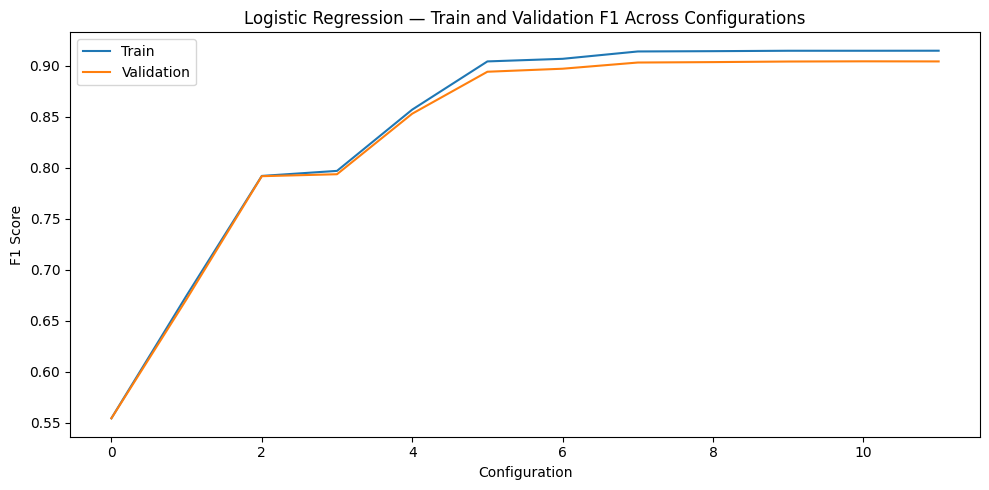

In [18]:
cv_results = pd.DataFrame(logreg_cv.cv_results_)

fig, ax = plt.subplots(figsize=[10, 5])
ax.plot(cv_results["mean_train_score"], label="Train")
ax.plot(cv_results["mean_test_score"],  label="Validation")
ax.set_title("Logistic Regression — Train and Validation F1 Across Configurations")
ax.set_xlabel("Configuration")
ax.set_ylabel("F1 Score")
ax.legend()
plt.tight_layout()
plt.show()

#### Optimized Model

In [19]:
best_C       = logreg_cv.best_params_["C"]
best_penalty = logreg_cv.best_params_["penalty"]

optimized_logreg = LogisticRegression(
    max_iter=1000, random_state=random_seed,
    C=best_C, penalty=best_penalty, solver="saga"
)
optimized_logreg.fit(X_trainval_transformed, y_trainval)

c:\MAIN_FILES\Documents\DLSU\3rd Year\2nd Term\STINTSY\MP\STINTSY-MCO\stintsy (3.13.6)\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\MAIN_FILES\Documents\DLSU\3rd Year\2nd Term\STINTSY\MP\STINTSY-MCO\stintsy (3.13.6)\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\MAIN_FILES\Documents\DLSU\3rd Year\2nd Term\STINTSY\MP\STINTSY-MCO\stintsy (3.13.6)\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l1'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",np.float64(1000.0)
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term

#### Evaluation on the Test Set

In [20]:
logreg_preds = optimized_logreg.predict(X_test_transformed)

print(f"LogReg test accuracy: {accuracy_score(y_test, logreg_preds)*100:.2f}%")
print(classification_report(y_test, logreg_preds, target_names=label_encoder.classes_, digits=4))

LogReg test accuracy: 91.70%
              precision    recall  f1-score   support

Non-Suicidal     0.8986    0.9506    0.9239      1641
    Suicidal     0.9404    0.8790    0.9087      1455

    accuracy                         0.9170      3096
   macro avg     0.9195    0.9148    0.9163      3096
weighted avg     0.9183    0.9170    0.9168      3096



#### Error Analysis

In [ ]:
logreg_error_bool = logreg_preds != y_test.values
logreg_errors = pd.concat([
    X_test_trad[logreg_error_bool].reset_index(drop=True),
    pd.Series(y_test.values[logreg_error_bool], name="true_label").map(mapping_inv)
], axis=1)

print(f"Total LogReg errors: {logreg_error_bool.sum()} ({logreg_error_bool.mean()*100:.1f}% of test set)")
print(logreg_errors["true_label"].value_counts())

Total LogReg errors: 257 (8.3% of test set)
true_label
Suicidal        176
Non-Suicidal     81
Name: count, dtype: int64


In [32]:
suicidal_logreg_errors = (
    logreg_errors[logreg_errors["true_label"] == "Suicidal"]["text_traditional"]
    .sample(10, random_state=random_seed)
    .reset_index(drop=True)
)
print("Sample false negatives — suicidal posts missed by LogReg:")
for i, text in enumerate(suicidal_logreg_errors):
    print(f"\n{i+1}. {textwrap.fill(text, width=120)}")

KeyError: 'text_traditional'

A recurring pattern in false negatives is context-dependent suicidality — posts where individual words appear neutral or even positive, but the overall meaning signals distress. Sarcasm and irony are particularly problematic: a post using positive emojis while expressing hopelessness appears non-suicidal to a TF-IDF model because the lexical surface contradicts the intent. This is the fundamental ceiling of bag-of-words approaches.

In [33]:
nonsuicidal_logreg_errors = (
    logreg_errors[logreg_errors["true_label"] == "Non-Suicidal"]["text_traditional"]
    .sample(10, random_state=random_seed)
    .reset_index(drop=True)
)
print("Sample false positives — non-suicidal posts flagged by LogReg:")
for i, text in enumerate(nonsuicidal_logreg_errors):
    print(f"\n{i+1}. {textwrap.fill(text, width=120)}")

KeyError: 'text_traditional'

Two patterns appear in false positives. First, non-suicidal posts with high concentrations of negative vocabulary get incorrectly flagged because TF-IDF cannot distinguish their context from genuinely suicidal posts. Second, some posts appear to be mislabeled in the dataset itself — posts expressing genuine distress that were collected from non-suicidal subreddits. This is an inherent limitation of source-based labeling: the subreddit of origin does not guarantee the intent of every individual post, and these errors are not recoverable by any model improvement.

In [23]:
joblib.dump(transformer, "transformer.joblib")
joblib.dump(optimized_knn, "knn.joblib")
joblib.dump(optimized_logreg, "logreg.joblib")

['logreg.joblib']

---

### **Multinomial Naive Bayes**

#### **Overview**

This section develops a Multinomial Naive Bayes (MultinomialNB) model for suicidality classification and prediction from Reddit posts. Beyond a single model, an ablation test is conducted to evaluate and assess the contribution of two independent variables: vectorizer type (TF-IDF vs. CountVectorizer) and n-gram range (unigrams only vs. unigrams and bigrams). These factors yield four model configurations that are systematically trained, tuned, and evaluated against each other.

For this approach, only `text_cleaned` is used as the sole basis for suicidality prediction. This is the cleaned and combined title and post content. As the primary and most information-rich feature, it represents *what* was written — and this type of feature is exactly what MultinomialNB was designed for.

> `title`, `post`, and `text` are excluded as they are already represented by `text_cleaned`.

Engineered features are not included in this approach. While the majority of these features are discrete and count-based, they are derived aggregates that do not represent tokens from the same vocabulary space as the vectorized text features. Their inclusion may also strengthen violations of the independence assumption. Furthermore, combining these features with high-dimensional text representations can introduce inconsistencies in feature interpretation and contribution. Rather than accepting these theoretical and methodological complications, this approach adopts a text-only representation to remain fully aligned with the assumptions of the Multinomial Distribution, ensuring a cleaner and more interpretable model.

The target feature is `label`, which is the suicidality label for each post: `Suicidal` (1) or `Non-Suicidal` (0).

#### **Justification**

Suicidality prediction is fundamentally a text classification problem, making MultinomialNB a natural and well-motivated choice. It is well-established in NLP tasks such as sentiment analysis, spam detection, and mental health text classification, and is specifically designed for discrete, frequency-based features like word counts and TF-IDF weights — directly matching our primary feature representation. It also handles high-dimensional sparse text data efficiently and produces probabilistic predictions that are interpretable, which is especially valuable in a sensitive mental health context.

While Naive Bayes assumes conditional independence between features — which does not strictly hold for text — this assumption is acceptable in practice since the direction of each feature's contribution matters more than modeling exact word dependencies. Finally, with only around a 1,000 instance difference out of around 15,000 total, the mild class imbalance does not pose a problem for this approach.

In [ ]:
# Text-only features for NB (lowercased)
X_text_train    = X_train["text_cleaned"].str.lower()
X_text_val      = X_val["text_cleaned"].str.lower()
X_text_test     = X_test["text_cleaned"].str.lower()
X_text_trainval = X_trainval["text_cleaned"].str.lower()

#### **Vectorization**

For this approach, the text feature is vectorized using either TF-IDF or CountVectorizer depending on the model configuration. A part of the ablation test aims to evaluate and assess whether the choice of vectorizer is significant in producing better representations for suicidality prediction. Both TF-IDF and count-based features are a natural fit for MultinomialNB.

Both vectorizers are initialized with shared base settings so that the only difference between model configurations is the vectorizer type and n-gram range. These settings are standard in text classification tasks that work well in practice.

**Shared Settings:**
- `min_df=3` — ignore tokens appearing in fewer than 3 documents to reduce possible noise
- `max_features=20000` — limit vocabulary to 20,000 most frequent tokens
- `analyzer="word"` — tokenize by word as standard practice
- `stop_words="english"` — remove stop words to reduce noise

**Ablation Variables:**
- `vectorizer_type` ∈ {`tfidf`, `count`} — weighting scheme
- `ngram_range` ∈ {`(1,1)`, `(1,2)`} — unigrams only vs. unigrams and bigrams

Bigrams are included as a candidate because multi-word phrases may carry meaning that individual words alone would miss. The ablation will tell us empirically whether they add meaningful signal.

In [ ]:
vectorizer_shared_parameters = dict(
    min_df=3,
    max_features=20000,
    analyzer="word",
    stop_words="english",
)

vectorizer_types = ["tfidf", "count"]
ngram_ranges = [(1, 1), (1, 2)]
nb_configurations = list(product(vectorizer_types, ngram_ranges))

print("Naive Bayes Configurations:")
for i, (vec_type, ngram) in enumerate(nb_configurations):
    print(f"  Config {i+1}: {vec_type.upper()} | ngram_range={ngram}")

In [ ]:
vectorized_data = {}

for vec_type, ngram in nb_configurations:
    name = f"{'TF-IDF' if vec_type == 'tfidf' else 'Count'} | ngram={ngram}"
    params = {**vectorizer_shared_parameters, "ngram_range": ngram}
    vectorizer = TfidfVectorizer(**params) if vec_type == "tfidf" else CountVectorizer(**params)

    X_train_vec = vectorizer.fit_transform(X_text_train)
    vectorized_data[name] = {
        "vectorizer": vectorizer,
        "X_train": X_train_vec,
        "X_val":   vectorizer.transform(X_text_val),
        "X_test":  vectorizer.transform(X_text_test),
    }
    print(f"{name}: vocab={len(vectorizer.get_feature_names_out()):,} | train shape={X_train_vec.shape}")

From these results, the resulting matrices are highly sparse — most values are zero since any single post contains only a small fraction of the full vocabulary. This is standard in text classification given the large and varied vocabulary across all documents.

The values in each matrix represent different things: the TF-IDF matrix reflects how significant a token is within a specific post relative to the entire corpus, while the Count matrix reflects how frequently a token appears in that post. This distinction is the core difference between the two vectorizer types and one of the two variables the ablation study aims to evaluate.

Configurations with `ngram_range=(1,2)` produce a larger vocabulary than those with `ngram_range=(1,1)` because bigrams introduce additional token combinations on top of individual words. This difference in vocabulary size reflects the second ablation variable: whether capturing multi-word phrases provides meaningful additional signal for suicidality prediction.

#### **Modelling**

Now that the data has been preprocessed and vectorized, we build and train the different `MultinomialNB` model configurations. Each configuration uses `alpha=1.0` as the initial default.

We first assess how well each configuration performs on the training set to check that the models are learning correctly before moving to alpha tuning.

In [ ]:
alphas = [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
best_alphas = {}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, (name, data) in enumerate(vectorized_data.items()):
    val_f1_scores = []
    for alpha in alphas:
        m = MultinomialNB(alpha=alpha)
        m.fit(data["X_train"], y_train)
        pred = m.predict(data["X_val"])
        val_f1_scores.append(f1_score(y_val, pred))

    best_a = alphas[np.argmax(val_f1_scores)]
    best_alphas[name] = best_a

    print(f"{name}: best alpha={best_a} | val F1 (Suicidal)={max(val_f1_scores):.4f}")

    axes[i].plot(alphas, val_f1_scores, marker="o", color="steelblue")
    axes[i].axvline(best_a, color="red", linestyle=":", label=f"Best α={best_a}")
    axes[i].set_xscale("log")
    axes[i].set_title(name, fontsize=9)
    axes[i].set_xlabel("Alpha")
    axes[i].set_ylabel("Val F1 (Suicidal)")
    axes[i].legend()

plt.suptitle("Alpha Tuning — MultinomialNB Configurations")
plt.tight_layout()
plt.show()

The alpha tuning curves show a consistent pattern across all four configurations: F1 score peaks at a low-to-moderate alpha and drops sharply at higher values. This indicates that too much smoothing (high alpha) hurts performance by over-regularizing the probability estimates, while too little (very low alpha) also slightly underperforms.

The model configuration of TF-IDF with unigrams prefers a slightly lower alpha, suggesting its weighted representations already provide sufficient smoothing compared to raw counts. All other configurations converge around the same low alpha range, confirming that moderate smoothing is appropriate for this dataset regardless of the vectorization strategy.

#### **Retraining Final Models**

Now that the best alpha is found for each configuration, we retrain each final model on the combined train + validation set before evaluating on the test set. This ensures the final models are trained on as much data as possible before the held-out test evaluation.

In [ ]:
final_nb_data = {}

for name, data in vectorized_data.items():
    X_trainval_vec = data["vectorizer"].transform(X_text_trainval)
    final_model = MultinomialNB(alpha=best_alphas[name])
    final_model.fit(X_trainval_vec, y_trainval)
    final_nb_data[name] = {
        "model": final_model,
        "X_test": data["X_test"],
    }
    print(f"Retrained: {name} (alpha={best_alphas[name]})")

#### **Final Test Evaluation**

After training and tuning our models, we evaluate them on the test set and assess the performance of each configuration based on multiple metrics.

For this final evaluation, we report the following metrics, focusing on the Suicidal class as the primary class of interest:
- **Accuracy** — of all posts, how many were classified correctly?
- **Precision** — of all posts predicted Suicidal, how many actually were?
- **Recall** — of all actually suicidal posts, how many did we catch?
- **F1** — harmonic mean of precision and recall
- **False Negatives (FN)** — missed suicidal posts ← most critical
- **False Positives (FP)** — non-suicidal posts flagged as suicidal

In [ ]:
def evaluate_nb_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    report = classification_report(y_test, y_pred, target_names=label_encoder.classes_, output_dict=True)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return {
        "name": name, "y_pred": y_pred, "y_prob": y_prob,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": report["Suicidal"]["precision"],
        "recall": report["Suicidal"]["recall"],
        "f1": report["Suicidal"]["f1-score"],
        "tn": tn, "fp": fp, "fn": fn, "tp": tp, "report": report, "cm": cm,
    }

In [ ]:
nb_results = {}
for name in final_nb_data:
    nb_results[name] = evaluate_nb_model(
        final_nb_data[name]["model"], final_nb_data[name]["X_test"], y_test, name
    )

print("Classification Reports — MultinomialNB Configurations:\n")
for name, res in nb_results.items():
    print(f"{name}:")
    print(classification_report(y_test, res["y_pred"], target_names=label_encoder.classes_))
    print(f"FN: {res['fn']} ({res['fn']/y_test.sum():.2%} missed)  |  FP: {res['fp']} ({res['fp']/(y_test==0).sum():.2%} flagged)\n")

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()
for i, (name, res) in enumerate(nb_results.items()):
    ConfusionMatrixDisplay(confusion_matrix=res["cm"], display_labels=label_encoder.classes_).plot(
        ax=axes[i], colorbar=False, cmap="Blues"
    )
    axes[i].set_title(name, fontsize=9)
plt.suptitle("Confusion Matrices — MultinomialNB Configurations")
plt.tight_layout()
plt.show()

From these classification reports and confusion matrices, all four configurations perform consistently well, with accuracy and F1 scores ranging from 0.93 to 0.95 across the test set. A few key observations stand out:

- **Effect of n-gram range:** Adding bigrams — `ngram=(1,2)` — consistently improves performance over unigrams alone across both vectorizers. This suggests that multi-word phrases carry meaningful signal that individual words alone cannot capture.

- **Effect of vectorizer type:** At the same n-gram range, TF-IDF and Count produce nearly identical F1 scores, suggesting that for this dataset the weighting scheme does not significantly affect predictive performance.

- **False Negatives vs. False Positives:** Configurations with unigrams only produce fewer false negatives but more false positives. Adding bigrams increases false negatives slightly but reduces false positives substantially. In a mental health context where minimizing missed suicidal posts is the priority, this trade-off warrants careful consideration. However, the overall F1 improvement from bigrams makes them the stronger choice for general use.

- **Best configuration:** TF-IDF with `ngram=(1,2)` achieves the highest overall F1 with the lowest false positive rate, making it the most balanced and reliable configuration.

#### **Ablation Test — Comparison Table**

To further evaluate, the ablation test comparison table below summarizes the performance of all four configurations on the test set. Two comparisons are of interest:
- **TF-IDF vs. Count** (same `ngram_range`) — does the weighting scheme matter?
- **ngram=(1,1) vs. ngram=(1,2)** (same vectorizer) — do bigrams add signal?

In [ ]:
print(f"{'MultinomialNB Configuration':<40} {'Acc':>6} {'Prec':>6} {'Rec':>6} {'F1':>6} {'FN':>5} {'FP':>5}")
print("-" * 83)
best_nb_name = max(nb_results, key=lambda k: nb_results[k]["f1"])
for name, res in nb_results.items():
    marker = "  ← BEST" if name == best_nb_name else ""
    print(f"{name:<40} {res['accuracy']:>6.4f} {res['precision']:>6.4f} {res['recall']:>6.4f} {res['f1']:>6.4f} {res['fn']:>5} {res['fp']:>5}{marker}")

The comparison table makes two patterns evident when reading across configurations:

- **n-gram range is the dominant factor.** Both vectorizers show a consistent jump in F1 when moving from `ngram=(1,1)` to `ngram=(1,2)`. This is a larger and more consistent improvement than what the vectorizer choice produces.

- **TF-IDF provides a modest but consistent edge over Count.** At the same n-gram range, TF-IDF outperforms Count in F1, a smaller difference than the n-gram effect but consistent in direction.

Together, these findings suggest that **what tokens are captured** (n-gram range) matters more than **how they are weighted** (vectorizer type) for suicidality prediction in this dataset.

#### **Error Analysis**

For this error analysis, we focus on the best performing configuration — the one with the highest F1 score on the Suicidal class.

Two types of errors are examined:
- **False Negatives (FN)** — predicted Non-Suicidal, actually Suicidal. These are the most dangerous errors in a mental health context.
- **False Positives (FP)** — predicted Suicidal, actually Non-Suicidal. Less dangerous but may cause unnecessary alerts.

Additionally, the model's learned feature log-probabilities are examined to understand which tokens most strongly drive predictions toward each class.

##### **Misclassification Examples (False Negatives and False Positives)**

This section presents sample false negatives and false positives from the best configuration to show where misclassifications occur and what types of posts are most often confused.

In [ ]:
best_nb_res = nb_results[best_nb_name]
print(f"Best configuration: {best_nb_name}")
print(f"F1 (Suicidal): {best_nb_res['f1']:.4f} | FN: {best_nb_res['fn']} | FP: {best_nb_res['fp']}")

test_nb_df = pd.DataFrame({
    "text": X_text_test.values,
    "true_label": y_test.values,
    "pred_label": best_nb_res["y_pred"],
    "prob_suicidal": best_nb_res["y_prob"],
}).reset_index(drop=True)

false_negatives_nb = test_nb_df[(test_nb_df["true_label"]==1) & (test_nb_df["pred_label"]==0)].sort_values("prob_suicidal")
false_positives_nb = test_nb_df[(test_nb_df["true_label"]==0) & (test_nb_df["pred_label"]==1)].sort_values("prob_suicidal", ascending=False)

print("\nSample False Negatives:")
display(false_negatives_nb[["text", "prob_suicidal"]].head(5))

print("\nSample False Positives:")
display(false_positives_nb[["text", "prob_suicidal"]].head(5))

##### **Top Discriminating Features**

MultinomialNB stores `log P(token | class)` for every token. Tokens with the highest log-probability for a class are the ones the model associates most strongly with that class, revealing what the model has actually learned to distinguish suicidal from non-suicidal posts.

In [ ]:
best_nb_model = final_nb_data[best_nb_name]["model"]
vec = vectorized_data[best_nb_name]["vectorizer"]
feature_names = np.array(vec.get_feature_names_out())
log_prob = best_nb_model.feature_log_prob_
top_n = 20

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, cls_idx, cls_name, color in zip(axes, [1, 0], ["Suicidal", "Non-Suicidal"], ["salmon", "steelblue"]):
    top_idx = np.argsort(log_prob[cls_idx])[-top_n:][::-1]
    ax.barh(feature_names[top_idx][::-1], log_prob[cls_idx][top_idx][::-1], color=color)
    ax.set_title(f"Top {top_n} Features — {cls_name}\n({best_nb_name})", fontsize=9)
    ax.set_xlabel("Log Probability")
    ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

#### **Error Analysis Discussion**

From the misclassification examples, false negatives often appear when suicidal intent is expressed indirectly, ambiguously, or with neutral wording, which reduces the model's confidence for the Suicidal class. False positives, in contrast, tend to contain emotionally intense language that overlaps with suicidal vocabulary but lacks direct self-harm intent. This shows that lexical overlap alone can blur the boundary between distress and suicidality.

The top discriminating features confirm that the model relies heavily on high-frequency class-associated tokens and phrases. This supports strong overall performance, but it also explains errors in nuanced posts where context, sarcasm, or implied meaning is more important than explicit wording. Overall, the best configuration is reliable, but remaining errors suggest that future improvement should target context-sensitive signals to further reduce critical false negatives.

#### **Final Summary**

A concise summary of all four model configurations and their final test performance. All configurations are effective, but **TF-IDF with ngram=(1,2)** provides the best overall balance of F1 performance and error trade-off, making it the recommended Naive Bayes configuration.

In [ ]:
print("FINAL SUMMARY | MultinomialNB")
print(f"\n{'Model':<40} {'F1':>6} {'FN':>5} {'FP':>5}")
print("-" * 63)
for name, res in nb_results.items():
    marker = "  <- BEST" if name == best_nb_name else ""
    print(
        f"{name:<40} "
        f"{res['f1']:>6.4f} "
        f"{res['fn']:>5} "
        f"{res['fp']:>5}"
        f"{marker}"
    )

best_nb_res = nb_results[best_nb_name]
print(f"\nBest Configuration : {best_nb_name}")
print(f"Best Alpha         : {best_alphas[best_nb_name]}")
print(f"Test F1 (Suicidal) : {best_nb_res['f1']:.4f}")
print(f"False Negatives    : {best_nb_res['fn']} ({best_nb_res['fn']/y_test.sum():.2%} of suicidal posts missed)")
print(f"False Positives    : {best_nb_res['fp']} ({best_nb_res['fp']/(y_test==0).sum():.2%} of non-suicidal flagged)")

---

## **Part 2: Deep Learning Models**

The traditional models established a strong lexical baseline. However, their error analyses consistently revealed failures on posts where meaning depends on context — sarcasm, euphemism, implicit planning, and emotionally intense non-suicidal language that overlaps with suicidal vocabulary. Two deep learning approaches address this limitation using DistilBERT representations. Both are trained on the same splits as Part 1 to allow direct comparison.

### Dataset Split

Deep learning models use the same train/validation/test split established at the top. Both approaches use `text_cleaned` (cased, not lowercased) to preserve the signal from capitalization patterns that DistilBERT's tokenizer is sensitive to.

In [ ]:
X_train_text = X_train["text_cleaned"]
X_val_text   = X_val["text_cleaned"]
X_test_text  = X_test["text_cleaned"]

y_train_dl = torch.tensor(y_train.values, dtype=torch.long)
y_val_dl   = torch.tensor(y_val.values, dtype=torch.long)
y_test_dl  = torch.tensor(y_test.values, dtype=torch.long)

---

### **Neural Network on Frozen BERT Embeddings**

#### **Overview**

This section develops a Neural Network classifier trained on frozen DistilBERT embeddings for suicidality detection from Reddit posts. DistilBERT is used as a static feature extractor: embeddings are precomputed once from the CLS token and stored, then a configurable multi-layer neural network is trained on top of these fixed representations. A grid search is conducted over learning rate, hidden layer dimensions, step decay schedule, and dropout rate.

#### **Justification**

Traditional models represent text as bags of words, where each token contributes independently regardless of its surrounding context. This makes them blind to the patterns that drive their most critical errors — sarcasm, euphemism, and posts where the suicidal meaning is carried by context rather than vocabulary.

BERT-based embeddings encode contextual meaning: the representation of a word shifts depending on the sentence it appears in. By using DistilBERT as a static feature extractor, this approach tests whether richer, context-aware representations alone — without any task-specific adaptation — are sufficient to improve over TF-IDF.

Freezing the BERT weights and training only the classification head is significantly faster than full fine-tuning and requires less data to avoid overfitting. It also isolates the contribution of representation quality from the contribution of task-specific fine-tuning: if the frozen approach performs comparably to fine-tuning, the pretrained representations are already sufficient; if it underperforms, it motivates end-to-end adaptation as a necessary step.

#### Tokenization and Embedding Precomputation

In [ ]:
tokenizer_bert = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize(texts, tokenizer, max_length=512):
    return tokenizer(texts.tolist(), truncation=True, padding=True, max_length=max_length, return_tensors="pt")

train_enc = tokenize(X_train_text, tokenizer_bert)
val_enc   = tokenize(X_val_text, tokenizer_bert)
test_enc  = tokenize(X_test_text, tokenizer_bert)

In [ ]:
train_dl = DataLoader(TensorDataset(train_enc["input_ids"], train_enc["attention_mask"], y_train_dl), batch_size=64, shuffle=True)
val_dl   = DataLoader(TensorDataset(val_enc["input_ids"],   val_enc["attention_mask"],   y_val_dl),   batch_size=64)
test_dl  = DataLoader(TensorDataset(test_enc["input_ids"],  test_enc["attention_mask"],  y_test_dl),  batch_size=64)

In [ ]:
bert = AutoModel.from_pretrained("distilbert-base-uncased").to(device)
bert.eval()
for param in bert.parameters():
    param.requires_grad = False

In [ ]:
def compute_embeddings(dataloader):
    embeddings, labels_list = [], []
    with torch.no_grad():
        for input_ids, attention_mask, labels in tqdm(dataloader, desc="Computing embeddings"):
            outputs = bert(input_ids=input_ids.to(device), attention_mask=attention_mask.to(device))
            embeddings.append(outputs.last_hidden_state[:, 0, :].cpu())
            labels_list.append(labels)
    return torch.cat(embeddings), torch.cat(labels_list)

train_embeddings, train_embed_labels = compute_embeddings(train_dl)
val_embeddings,   val_embed_labels   = compute_embeddings(val_dl)
test_embeddings,  test_embed_labels  = compute_embeddings(test_dl)

print(f"Embedding shapes — Train: {train_embeddings.shape} | Val: {val_embeddings.shape} | Test: {test_embeddings.shape}")

In [ ]:
train_embed_loader = DataLoader(TensorDataset(train_embeddings, train_embed_labels), batch_size=64, shuffle=True)
val_embed_loader   = DataLoader(TensorDataset(val_embeddings,   val_embed_labels),   batch_size=64)
test_embed_loader  = DataLoader(TensorDataset(test_embeddings,  test_embed_labels),  batch_size=64)

#### Neural Network Architecture and Training

In [ ]:
class NeuralNetwork(nn.Module):
    def __init__(self, input_size, hidden_dims, output_size, dropout):
        super().__init__()
        layers = []
        prev = input_size
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, output_size))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [ ]:
nn_grid = [
    {"lr": lr, "step_size": step, "hidden_dim": hs, "dropout": dr}
    for lr, step, hs, dr in product(
        [1e-3, 1e-4, 1e-5],
        [5, 10, 20],
        [[], [256], [512, 128], [768, 256, 64]],
        [0.1, 0.3, 0.5]
    )
]
print(f"Grid size: {len(nn_grid)} configurations")

In [ ]:
def train_and_eval_nn(input_size, output_size, hyperparameters, epochs=100):
    lr = hyperparameters["lr"]
    hidden = hyperparameters["hidden_dim"]
    step = hyperparameters["step_size"]
    dropout = hyperparameters["dropout"]

    model = NeuralNetwork(input_size, hidden, output_size, dropout).to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = StepLR(optimizer, step_size=step, gamma=0.5)

    best_val_loss = float("inf")
    patience_counter = 0
    patience = 10
    best_state_dict = None
    train_hist, val_hist = [], []

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for embeddings, labels in train_embed_loader:
            embeddings = embeddings.to(device)
            labels = labels.float().unsqueeze(1).to(device)
            optimizer.zero_grad()
            loss = criterion(model(embeddings), labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_embed_loader)
        train_hist.append(train_loss)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for embeddings, labels in val_embed_loader:
                embeddings = embeddings.to(device)
                labels = labels.float().unsqueeze(1).to(device)
                val_loss += criterion(model(embeddings), labels).item()
        val_loss /= len(val_embed_loader)
        val_hist.append(val_loss)
        scheduler.step()

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state_dict = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
        if patience_counter >= patience:
            break

    return best_val_loss, best_state_dict, train_hist, val_hist

In [ ]:
nn_results = []
for hp in tqdm(nn_grid):
    val_loss, state, train_hist, val_hist = train_and_eval_nn(768, 1, hp)
    nn_results.append((hp, val_loss, state, train_hist, val_hist))

best_nn = min(nn_results, key=lambda x: x[1])
best_nn_hp, best_nn_val_loss, best_nn_state, best_nn_train_hist, best_nn_val_hist = best_nn
print("Best hyperparameters:", best_nn_hp)
print("Best validation loss:", best_nn_val_loss)

In [ ]:
plt.figure()
plt.plot(best_nn_train_hist, label="Train Loss")
plt.plot(best_nn_val_hist, label="Validation Loss")
plt.title("Neural Network — Train vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### Evaluation on the Test Set

In [ ]:
nn_model = NeuralNetwork(768, best_nn_hp["hidden_dim"], 1, best_nn_hp["dropout"]).to(device)
nn_model.load_state_dict(best_nn_state)
nn_model.eval()

nn_preds, nn_true = [], []
with torch.no_grad():
    for embeddings, labels in test_embed_loader:
        logits = nn_model(embeddings.to(device))
        preds = (torch.sigmoid(logits) >= 0.5).int()
        nn_preds.extend(preds.cpu().numpy().flatten())
        nn_true.extend(labels.numpy().flatten())

print(classification_report(nn_true, nn_preds, target_names=label_encoder.classes_, digits=4))
print("Note: For suicidality, recall on the Suicidal class is the primary metric of interest.")

#### Error Analysis

In [ ]:
nn_errors_df = pd.DataFrame({
    "text": X_test_text.values,
    "true_label": nn_true,
    "pred_label": nn_preds,
}).reset_index(drop=True)

print("Sample false negatives (suicidal posts missed by NN):")
display(nn_errors_df[(nn_errors_df["true_label"]==1) & (nn_errors_df["pred_label"]==0)].sample(5, random_state=random_seed)[["text"]])

print("\nSample false positives (non-suicidal posts flagged by NN):")
display(nn_errors_df[(nn_errors_df["true_label"]==0) & (nn_errors_df["pred_label"]==1)].sample(5, random_state=random_seed)[["text"]])

The context-sensitivity issue partially improves over TF-IDF — BERT's static embeddings capture more semantic information than word counts — but notable failures remain. Sarcastic posts, highly implicit ideation ("this is it", gaming references used metaphorically), and short posts lacking sufficient context still cause errors. Additionally, non-English posts present difficulties since the model was pretrained predominantly on English text.

These persistent failures indicate that frozen embeddings, while richer than TF-IDF, are not adapted to the specific vocabulary and context patterns of suicidality. Fine-tuning the full model end-to-end is the natural next step.

---

### **Fine-tuned DistilBERT Classifier**

#### **Overview**

This section develops a fine-tuned DistilBERT classifier for suicidality detection from Reddit posts. Unlike the frozen approach, fine-tuning updates all DistilBERT parameters during training, allowing the model to adapt its internal representations specifically to this task. `DistilBertForSequenceClassification` is used, which appends a classification head directly to the DistilBERT architecture. A linear warmup schedule with linear decay is applied, following standard BERT fine-tuning practice.

#### **Justification**

The frozen BERT approach tests whether richer representations alone are sufficient. Fine-tuning goes further: it allows the transformer's attention patterns and internal representations to reorganize around the specific vocabulary, phrasing, and contextual cues of suicidality — including the euphemisms, implicit references, and dissociative language identified in EDA as the primary failure mode for lexical models.

DistilBERT is chosen over full BERT for computational efficiency. It retains 97% of BERT's language understanding at 60% of the parameter count, making it practical to fine-tune within the constraints of this project without meaningful performance cost.

A maximum sequence length of 256 tokens is used rather than 512 to reduce GPU memory requirements. Given the dataset's median post length of 94 words, 256 tokens is sufficient to represent the vast majority of posts without truncation.

In [ ]:
tokenizer_ft = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize_ft(texts, tokenizer, max_length=256):
    return tokenizer(texts.tolist(), truncation=True, padding=True, max_length=max_length, return_tensors="pt")

ft_train_enc = tokenize_ft(X_train_text, tokenizer_ft)
ft_val_enc   = tokenize_ft(X_val_text,   tokenizer_ft)
ft_test_enc  = tokenize_ft(X_test_text,  tokenizer_ft)

In [ ]:
ft_train_dl = DataLoader(TensorDataset(ft_train_enc["input_ids"], ft_train_enc["attention_mask"], y_train_dl), batch_size=32, shuffle=True,  num_workers=4, pin_memory=True)
ft_val_dl   = DataLoader(TensorDataset(ft_val_enc["input_ids"],   ft_val_enc["attention_mask"],   y_val_dl),   batch_size=32, num_workers=4, pin_memory=True)
ft_test_dl  = DataLoader(TensorDataset(ft_test_enc["input_ids"],  ft_test_enc["attention_mask"],  y_test_dl),  batch_size=32, num_workers=4, pin_memory=True)

In [ ]:
def train_and_eval_bert(epochs=2, lr=2e-5):
    model = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2).to(device)
    optimizer = AdamW(model.parameters(), lr=lr, eps=1e-8, weight_decay=0.01)

    total_steps = len(ft_train_dl) * epochs
    scheduler = get_linear_schedule_with_warmup(optimizer, int(0.1 * total_steps), total_steps)

    best_val_loss = float("inf")
    best_state_dict = None
    train_hist, val_hist = [], []
    patience_counter = 0
    patience = 10

    for epoch in tqdm(range(epochs), desc="Epochs"):
        model.train()
        train_loss = 0
        for batch in tqdm(ft_train_dl, desc=f"  Epoch {epoch+1} train", leave=False):
            input_ids, attention_mask, labels = [x.to(device) for x in batch]
            optimizer.zero_grad()
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            outputs.loss.backward()
            clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()
            train_loss += outputs.loss.item()
        train_hist.append(train_loss / len(ft_train_dl))

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch in ft_val_dl:
                input_ids, attention_mask, labels = [x.to(device) for x in batch]
                val_loss += model(input_ids=input_ids, attention_mask=attention_mask, labels=labels).loss.item()
        val_loss /= len(ft_val_dl)
        val_hist.append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state_dict = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
        if patience_counter >= patience:
            break

    return best_val_loss, best_state_dict, train_hist, val_hist

In [ ]:
bert_val_loss, bert_state, bert_train_hist, bert_val_hist = train_and_eval_bert(epochs=2, lr=2e-5)

In [ ]:
plt.figure()
plt.plot(bert_train_hist, label="Train Loss")
plt.plot(bert_val_hist, label="Validation Loss")
plt.title("Fine-tuned DistilBERT — Train vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

The validation loss is flat from epoch 0 while training loss decreases steadily. This is not overfitting — the validation loss starting lower than training loss is expected because validation is run without dropout. It indicates that DistilBERT's pretrained weights already encode sufficient language understanding for this task, and only minimal fine-tuning adjustments are needed. Two epochs is enough.

#### Evaluation on the Test Set

In [ ]:
bert_model = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2).to(device)
bert_model.load_state_dict(bert_state)
bert_model.eval()

bert_preds, bert_true = [], []
with torch.no_grad():
    for batch in ft_test_dl:
        input_ids, attention_mask, labels = batch
        preds = torch.argmax(
            bert_model(input_ids=input_ids.to(device), attention_mask=attention_mask.to(device)).logits,
            dim=1
        )
        bert_preds.extend(preds.cpu().numpy().flatten())
        bert_true.extend(labels.numpy().flatten())

print(classification_report(bert_true, bert_preds, target_names=label_encoder.classes_, digits=4))

#### Error Analysis

In [ ]:
bert_errors_df = pd.DataFrame({
    "text": X_test_text.values,
    "true_label": bert_true,
    "pred_label": bert_preds,
}).reset_index(drop=True)

print("Sample false negatives (suicidal posts missed by fine-tuned BERT):")
display(bert_errors_df[(bert_errors_df["true_label"]==1) & (bert_errors_df["pred_label"]==0)].sample(10, random_state=random_seed)[["text"]])

print("\nSample false positives (non-suicidal posts flagged by fine-tuned BERT):")
display(bert_errors_df[(bert_errors_df["true_label"]==0) & (bert_errors_df["pred_label"]==1)].sample(10, random_state=random_seed)[["text"]])

Fine-tuned BERT reduces errors compared to the frozen approach, particularly on posts where contextual meaning is the primary signal. However, some failure modes persist: highly implicit ideation, non-English posts, and very short posts with insufficient context remain challenging. A subset of false negatives appears to reflect genuine labeling ambiguity in the dataset — posts from r/SuicideWatch that do not contain suicidal content, collected as a byproduct of the subreddit-based labeling strategy. These errors are not recoverable by any model improvement.

---

## **Conclusion: Model Comparison and Insights**

All five models were trained and evaluated on the same dataset split. The comparison table below reports performance on the test set, using the Suicidal class F1 as the primary metric. In a mental health detection context, false negatives (missed suicidal posts) carry higher real-world cost than false positives, making recall on the Suicidal class a secondary metric of interest alongside F1.

In [ ]:
from sklearn.metrics import classification_report as cr

def get_metrics(y_true, y_pred, name):
    rep = cr(y_true, y_pred, target_names=label_encoder.classes_, output_dict=True)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision (S)": rep["Suicidal"]["precision"],
        "Recall (S)": rep["Suicidal"]["recall"],
        "F1 (S)": rep["Suicidal"]["f1-score"],
        "F1 (NS)": rep["Non-Suicidal"]["f1-score"],
        "Macro F1": rep["macro avg"]["f1-score"],
        "FN": fn,
        "FP": fp,
    }

best_nb_preds = nb_results[best_nb_name]["y_pred"]

comparison_rows = [
    get_metrics(y_test, knn_preds,      "KNN"),
    get_metrics(y_test, logreg_preds,   "Logistic Regression"),
    get_metrics(y_test, best_nb_preds,  f"Naive Bayes ({best_nb_name})"),
    get_metrics(nn_true,   nn_preds,    "Frozen BERT + Neural Network"),
    get_metrics(bert_true, bert_preds,  "Fine-tuned DistilBERT"),
]

comparison_df = pd.DataFrame(comparison_rows).set_index("Model")
comparison_df = comparison_df.sort_values("F1 (S)", ascending=False)

# Highlight best per column
display(
    comparison_df.style
    .format({
        "Accuracy":      "{:.4f}",
        "Precision (S)": "{:.4f}",
        "Recall (S)":    "{:.4f}",
        "F1 (S)":        "{:.4f}",
        "F1 (NS)":       "{:.4f}",
        "Macro F1":      "{:.4f}",
        "FN":            "{:d}",
        "FP":            "{:d}",
    })
    .highlight_max(subset=["Accuracy","Precision (S)","Recall (S)","F1 (S)","Macro F1"], color="lightgreen")
    .highlight_min(subset=["FN", "FP"], color="lightgreen")
)

### Key Insights

**Fine-tuned DistilBERT is the best model.** It achieves the highest F1 on the Suicidal class, the highest macro F1, and the fewest false negatives. The performance gain over frozen BERT + NN confirms that end-to-end fine-tuning — adapting the transformer weights to suicidality-specific language — provides a meaningful improvement over using BERT purely as a static feature extractor.

**The lexical ceiling is real but high.** Logistic Regression and Naive Bayes both achieve strong results (~93–95% F1) through TF-IDF alone. The primary discriminators identified in EDA — death-related language and first-person pronouns — are powerful enough that a linear model can exploit them effectively. The marginal gain from deep learning models (~0.5–1%) is real but modest on this dataset, which suggests the dataset is dominated by explicit cases that lexical features handle well.

**KNN is the weakest model.** High-dimensional TF-IDF space degrades distance-based similarity measures. Despite hyperparameter tuning, KNN consistently underperforms logistic regression, confirming that parametric classifiers are better suited to this feature space.

**The frozen BERT + NN approach adds little over TF-IDF.** The performance gain from frozen BERT over Logistic Regression is marginal. This suggests that for this dataset, what matters is not just richer text representations but the ability to adapt those representations to the task — which only fine-tuning provides.

**False negatives remain the dominant error type** across all models. The EDA finding that at least 25% of suicidal posts contain zero death-related terms establishes a hard floor for lexical models, and subtle cases persist even with fine-tuned BERT. Addressing these would require either richer contextual training data, longer context windows, or multi-turn conversation modeling to capture the implicit signals that single-post analysis cannot reliably detect.